In [1]:
import os
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint
import wandb
import torch.nn.functional as F


In [3]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

my_secret = user_secrets.get_secret("wandb_api") 

wandb.login(key=my_secret)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: da24m016 (da24m016-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

#### Sweep Config and common config

In [ ]:
## using 224x224 images
common_config = {
    "img_size": 224,
    "num_classes": 10,
    "batch_size": 32,
    "epochs": 10,
    "data_augmentation": True,
}

# Sweep config: we sweep over how many blocks to unfreeze, dropout, LR, and augmentation
sweep_config = {
    "method": "bayes",
    "metric": { "name": "val_acc", "goal": "maximize" },
    "parameters": {
        "freeze_before": { "values": [5, 7, 9] },
        "dropout":        { "values": [0.2, 0.3] },
        "learning_rate":  { "values": [1e-3, 1e-4] },
    }
}

sweep_id_partB = wandb.sweep(sweep_config, project="da6401_assignment2")
print("Sweep ID PartB:", sweep_id_partB)


Create sweep with ID: sp21o9r0
Sweep URL: https://wandb.ai/da24m016-indian-institute-of-technology-madras/da6401_assignment2/sweeps/sp21o9r0
Sweep ID PartB: sp21o9r0


In [ ]:
def prepare_data(config):
    train_tf = transforms.Compose([
        transforms.Resize((config["img_size"], config["img_size"])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    val_tf = transforms.Compose([
        transforms.Resize((config["img_size"], config["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    
    train_path = "../input/inaturalist_12K/train"
    test_path = "../input/inaturalist_12K/val"
    
    # Load and split
    full_train = datasets.ImageFolder(train_path, transform=train_tf)
    idx_by_class = {}
    for idx, (_,lbl) in enumerate(full_train.samples):
        idx_by_class.setdefault(lbl, []).append(idx)
    train_idx, val_idx = [], []
    for lbl, idxs in idx_by_class.items():
        np.random.shuffle(idxs)
        split = int(0.8*len(idxs))
        train_idx += idxs[:split]
        val_idx   += idxs[split:]
    train_ds = Subset(full_train, train_idx)
    
    full_train.transform = val_tf
    val_ds = Subset(full_train, val_idx)
    
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"],
                              shuffle=True, num_workers=4)
    val_loader   = DataLoader(val_ds, batch_size=config["batch_size"],
                              shuffle=False, num_workers=4)
    test_ds      = datasets.ImageFolder(test_path, transform=val_tf)
    test_loader  = DataLoader(test_ds, batch_size=config["batch_size"],
                              shuffle=False, num_workers=4)
    
    return train_loader, val_loader, test_loader, test_ds


#### Using EfficientNetV2 pretrained model

In [ ]:
## Using EfficientNetV2 small pretrained for our task
## We will freeze all but the last `freeze_before` blocks of the model.
## The last block is the classifier, so we will replace it with a dropout + linear layer.
class FineTuneEfficientNetV2(pl.LightningModule):
    def __init__(self, config):
        super().__init__()
        self.save_hyperparameters(config)
        
        self.net = models.efficientnet_v2_s(pretrained=True)
        total_blocks = len(self.net.features)
        freeze_upto = total_blocks - config["freeze_before"]
        
        # freezing all but last `freeze_before` blocks
        for idx, block in enumerate(self.net.features):
            for p in block.parameters():
                p.requires_grad = (idx >= freeze_upto)
        
        # replacing classifier with dropout + linear
        in_f = self.net.classifier[1].in_features
        self.net.classifier = nn.Sequential(
            nn.Dropout(config["dropout"]),
            nn.Linear(in_f, config["num_classes"])
        )
    
    def forward(self, x):
        return self.net(x)
    
    def training_step(self, batch, batch_idx):
        x,y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc  = (logits.argmax(dim=1)==y).float().mean()
        self.log("train_loss", loss)
        self.log("train_acc", acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x,y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc  = (logits.argmax(dim=1)==y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
    
    def test_step(self, batch, batch_idx):
        x,y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc  = (logits.argmax(dim=1)==y).float().mean()
        self.log("test_loss", loss)
        self.log("test_acc", acc)
    
    def configure_optimizers(self):
        params = filter(lambda p: p.requires_grad, self.parameters())
        return torch.optim.Adam(params, lr=self.hparams.learning_rate)


In [ ]:
def train():
    run    = wandb.init()
    sweep  = run.config
    params = {**common_config, **sweep}

    run.name = f"freeze{params['freeze_before']}_do{params['dropout']}_lr{params['learning_rate']}"
    run.save()

    train_loader, val_loader, test_loader = prepare_data(params)

    wandb_logger = WandbLogger(project="da6401_assignment2", log_model="all")
    ckpt_cb = ModelCheckpoint(
        monitor="val_acc", mode="max", save_top_k=1,
        dirpath="finetune_ckpts",
        filename=f"e2v2_fb{params['freeze_before']}_do{params['dropout']}_lr{params['learning_rate']}"
    )

    model = FineTuneEfficientNetV2(params)


    trainer = pl.Trainer(
        max_epochs=params["epochs"],                              
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        logger=wandb_logger,                                      
        callbacks=[ckpt_cb]                                       
    )


    trainer.fit(model, train_loader, val_loader)
    
    ## finding the test accuracy on the test set simultaneously
    trainer.test(model, test_loader)    

    # logging the best checkpoint as an artifact
    best_path = ckpt_cb.best_model_path
    artifact = wandb.Artifact("efficientnetv2_best", type="model")
    artifact.add_file(best_path)
    run.log_artifact(artifact)

    run.finish()


In [ ]:
wandb.agent(sweep_id_partB, function=train, count=10)

wandb: Agent Starting Run: pw53q7tt with config:
wandb: 	dropout: 0.3
wandb: 	freeze_before: 5
wandb: 	learning_rate: 0.001
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Tracking run with wandb version 0.19.6
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250417_190211-pw53q7tt
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run smart-sweep-1
wandb: ⭐️ View project at https://wandb.ai/da24m016-indian-institute-of-technology-madras/da6401_assignment2
wandb: 🧹 View sweep at https://wandb.ai/da24m016-indian-institute-of-technology-madras/da6401_assignment2/sweeps/sp21o9r0
wandb: 🚀 View run at https://wandb.ai/da24m016-indian-institute-of-technology-madras/da6401_assignment2/runs/pw53q7tt
wandb: WARNING Calling wandb.run.save without any arguments is deprecated.Changes to attributes are automatically persisted.
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: Use

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

wandb: WARNING Config item 'dropout' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'freeze_before' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8464999794960022     │
│         test_loss         │     0.655296802520752     │
└───────────────────────────┴───────────────────────────┘

wandb: uploading artifact efficientnetv2_best
wandb:                                                                                
wandb: 
wandb: Run history:
wandb:               epoch ▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇█
wandb:            test_acc ▁
wandb:           test_loss ▁
wandb:           train_acc ▁▃▅▅▄▆▆▆▇▅▇▆▇█▆█▇███▇▇▇▇██▇▇▇▇██▇▇▇▇█▇▆█
wandb:          train_loss █▅▃▅▂▂▂▃▃▂▂▃▁▂▁▁▁▁▁▂▁▁▂▁▁▁▁▁▁▂▁▁▁▁▁▂▁▁▂▁
wandb: trainer/global_step ▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
wandb:             val_acc ▁▄▄▅▆█▂▄▅▅
wandb:            val_loss ▂▁▃▃█▃▅▇▅▅
wandb: 
wandb: Run summary:
wandb:               epoch 10
wandb:            test_acc 0.8465
wandb:           test_loss 0.6553
wandb:           train_acc 1
wandb:          train_loss 0.00362
wandb: trainer/global_step 2500
wandb:             val_acc 0.857
wandb:            val_loss 0.64029
wandb: 
wandb: 🚀 View run freeze9_do0.3_lr0.0001 at: https://wandb.ai/da24m016-indian-institute-of-technology-madras/da6401_assignment2/runs/hp

#### Progressive Unfreezing Strategy

In [ ]:

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint
import wandb


best_params = {
    "img_size": 224,
    "num_classes": 10,
    "batch_size": 32,
    "epochs_per_stage": 5,   
    "data_augmentation": True,
    "freeze_before": 7,     
    "dropout": 0.3,
    "learning_rate": 1e-4
}

def prepare_data(params):
    train_tf = transforms.Compose([
        transforms.Resize((params["img_size"], params["img_size"])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    val_tf = transforms.Compose([
        transforms.Resize((params["img_size"], params["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    train_path = "/kaggle/input/inaturalist_12K/train"
    test_path  = "/kaggle/input/inaturalist_12K/test"
    if not os.path.isdir(test_path):
        test_path = "/kaggle/input/inaturalist_12K/val"
    full = datasets.ImageFolder(train_path, transform=train_tf)
    idxs_by_cls = {}
    for idx,(_,lbl) in enumerate(full.samples):
        idxs_by_cls.setdefault(lbl, []).append(idx)
    train_idx, val_idx = [], []
    for lbl, idxs in idxs_by_cls.items():
        np.random.shuffle(idxs)
        cut = int(0.8 * len(idxs))
        train_idx += idxs[:cut]
        val_idx   += idxs[cut:]
    train_ds = Subset(full, train_idx)
    full.transform = val_tf
    val_ds   = Subset(full, val_idx)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  num_workers=4)
    val_loader   = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False, num_workers=4)
    test_ds      = datasets.ImageFolder(test_path, transform=val_tf)
    test_loader  = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, num_workers=4)
    return train_loader, val_loader, test_loader, test_ds

train_loader, val_loader, test_loader, test_dataset = prepare_data(best_params)



class FineTuneE2VS(pl.LightningModule):
    def __init__(self, p):
        super().__init__()
        self.save_hyperparameters(p)
        self.net = models.efficientnet_v2_s(pretrained=True)
        # freeze all feature blocks initially
        for block in self.net.features:
            for param in block.parameters():
                param.requires_grad = False
        # replace classifier head
        in_f = self.net.classifier[1].in_features
        self.net.classifier = nn.Sequential(
            nn.Dropout(p["dropout"]),
            nn.Linear(in_f, p["num_classes"])
        )
    def forward(self, x):
        return self.net(x)
    def _step(self, batch, tag):
        x,y    = batch
        logits = self(x)
        loss   = F.cross_entropy(logits, y)
        acc    = (logits.argmax(dim=1)==y).float().mean()
        self.log(f"{tag}_loss", loss, prog_bar=True)
        self.log(f"{tag}_acc",  acc,  prog_bar=True)
        return loss
    def training_step(self, batch, batch_idx): return self._step(batch, "train")
    def validation_step(self, batch, batch_idx): return self._step(batch, "val")
    def test_step(self, batch, batch_idx):       return self._step(batch, "test")
    def configure_optimizers(self):
        params = filter(lambda p: p.requires_grad, self.parameters())
        return torch.optim.Adam(params, lr=self.hparams["learning_rate"])


def set_unfreeze(model, unfreeze_blocks):
    total = len(model.net.features)
    for idx, block in enumerate(model.net.features):
        requires = idx >= (total - unfreeze_blocks)
        for p in block.parameters():
            p.requires_grad = requires


wandb.init(project="da6401_assignment2", name="PartB_progressive_unfreeze")
wandb_logger = WandbLogger(log_model="all")
ckpt_cb = ModelCheckpoint(
    monitor="val_acc", mode="max", save_top_k=1,
    dirpath="prog_unfreeze_ckpts",
    filename="e2v2s_unfreeze{epoch:02d}-{val_acc:.3f}"
)


model = FineTuneE2VS(best_params)

## stages for progressive unfreezing

stages = [
    ("Stage1_head",        0),
    ("Stage2_last1block",  1),
    ("Stage3_last2blocks", 2),
    ("Stage4_all",         len(model.net.features))
]

for name, unfreeze_blocks in stages:
    set_unfreeze(model, unfreeze_blocks)
    trainer = pl.Trainer(
        max_epochs=best_params["epochs_per_stage"],
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        precision=16,
        logger=wandb_logger,
        callbacks=[ckpt_cb]
    )
    print(f"\n=== {name}: unfreeze_blocks={unfreeze_blocks} ===")
    trainer.fit(model, train_loader, val_loader)



best_path = ckpt_cb.best_model_path
print("Loading best checkpoint:", best_path)
best_model = FineTuneE2VS.load_from_checkpoint(best_path, best_params)
best_model.eval()
if torch.cuda.is_available():
    best_model.to("cuda")

trainer = pl.Trainer(accelerator="gpu" if torch.cuda.is_available() else "cpu",
                     precision=16)
res = trainer.test(best_model, test_loader)
print(f"Final Test Accuracy: {res[0]['test_acc']:.4f}")


artifact = wandb.Artifact("PartB_prog_unfreeze_best", type="model")
artifact.add_file(best_path)
wandb.log_artifact(artifact)


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 195MB/s] 
/usr/local/lib/python3.11/dist-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged.


=== Stage1_head: unfreeze_blocks=0 ===


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

2025-04-18 09:46:24.986975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744969585.540913      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744969585.691699      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8289999961853027     │
│         test_loss         │    0.7540643811225891     │
└───────────────────────────┴───────────────────────────┘

Final Test Accuracy: 0.8290


<Artifact PartB_prog_unfreeze_best>

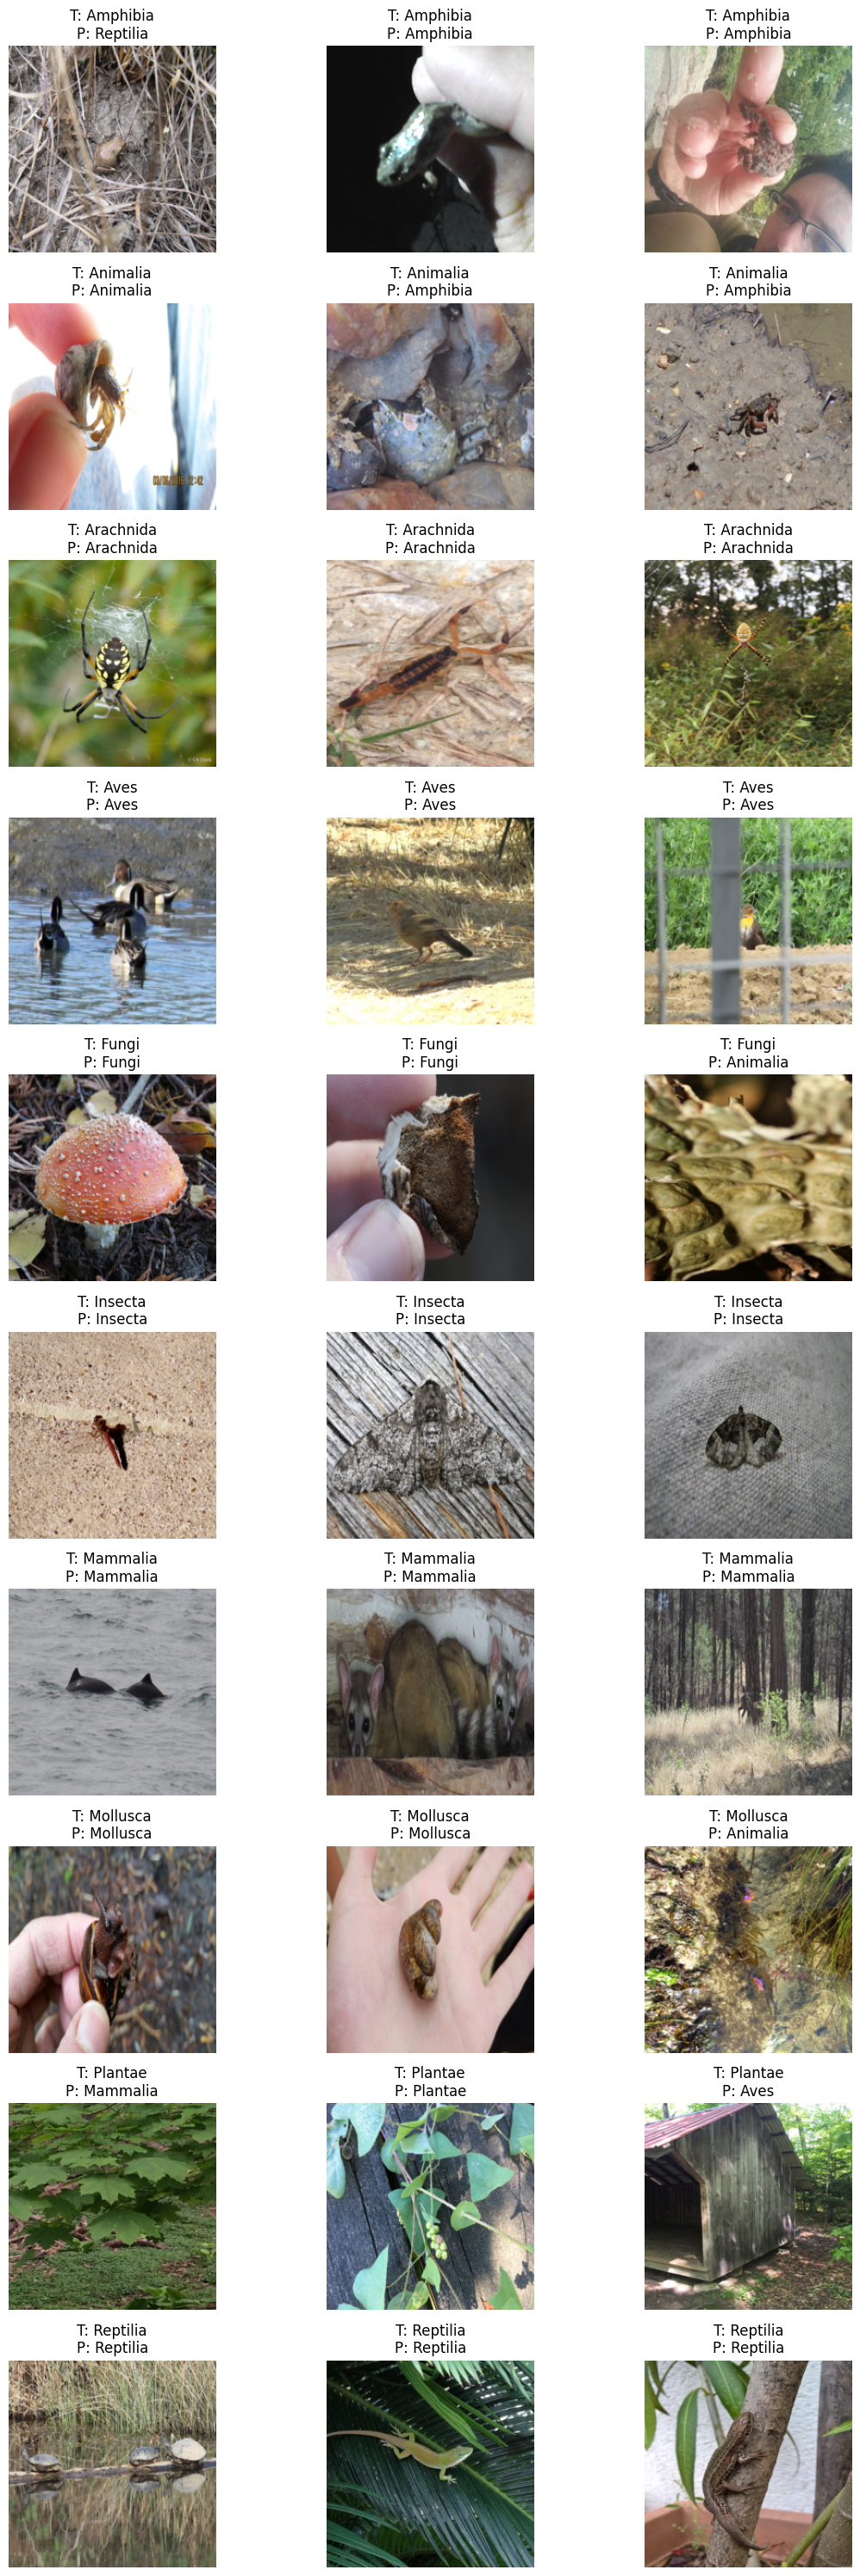

epoch,▁▁▁▁▃▃▃▅▆▆███▁▁▅▅▅▅▅▁▃▃▃▅▆▆▆██▁▃▅▅▅▆▆▆██
train_acc,▁▁▃▅▃▅▃▅▅▅▅▄▆▆▅▆▇▅▄▆▆▆▇▇██████▇████▇▇██▇
train_loss,██▇▇▆▆▅▅▅▅▅▄▅▄▄▄▄▄▃▄▄▃▄▃▂▁▁▃▂▂▂▁▁▁▁▁▁▁▁▁
trainer/global_step,▂▃▄▄▅▆▆▇▇█▂▃▄▄▄▅▆▇▇▇█▁▂▂▃▃▅▅▇▇▇█▁▂▂▃▄▄▆█
val_acc,▁▃▃▄▄▄▅▅▅▅██████▇███
val_loss,█ ▆▅▄▄▃▃▂▂▁▁▁▁▂▂ ▂▂▂
epoch,4
train_acc,0.90323
train_loss,0.16835
trainer/global_step,1249
val_acc,0.8325


In [ ]:
# loading the best model for inference
import torch
import matplotlib.pyplot as plt
import wandb

samples = {i: [] for i in range(best_params["num_classes"])}
for img, lbl in test_dataset:
    if len(samples[lbl]) < 3:
        samples[lbl].append(img)
    if all(len(v) == 3 for v in samples.values()):
        break

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(device)

# Get predictions from best_model
preds = {}
for cls, imgs in samples.items():
    batch = torch.stack(imgs).to(device)
    out = best_model(batch)
    preds[cls] = out.argmax(1).cpu().tolist()

def denormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    img = t.cpu() * std + mean
    return img.clamp(0, 1)

# Plotting the 10×3 grid
class_names = test_dataset.classes
fig, axes = plt.subplots(best_params["num_classes"], 3, figsize=(12, 30))
for cls in range(best_params["num_classes"]):
    for j in range(3):
        img = denormalize(samples[cls][j])
        ax = axes[cls][j]
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(f"T: {class_names[cls]}\nP: {class_names[preds[cls][j]]}")
        ax.axis("off")

plt.tight_layout()
plt.savefig("PartB_prog_unfreeze_grid.png")
plt.show()

wandb.log({"PartB_prog_unfreeze_grid": wandb.Image("PartB_prog_unfreeze_grid.png")})
wandb.finish()
